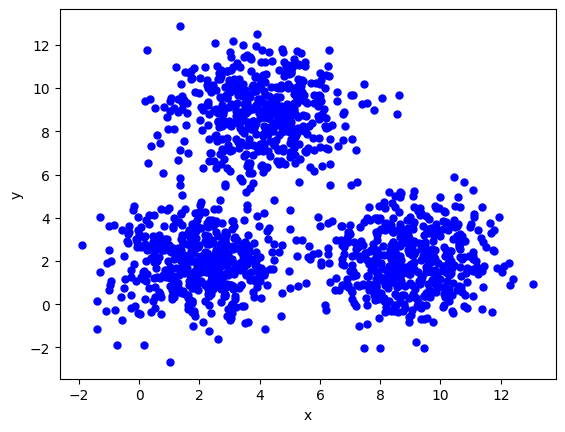

[[4.23321626 0.8940023 ]
 [1.71575367 0.87825932]
 [2.37192679 0.78856002]]


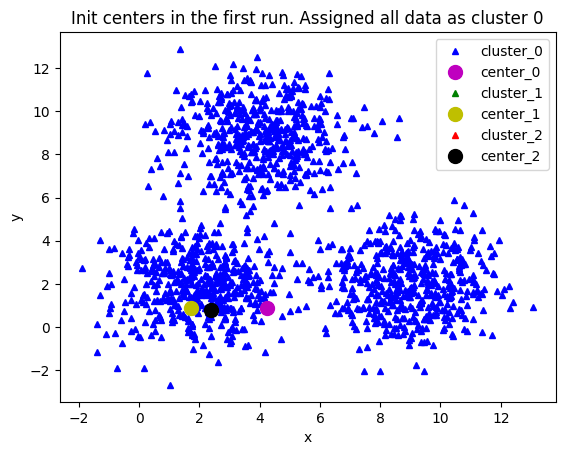

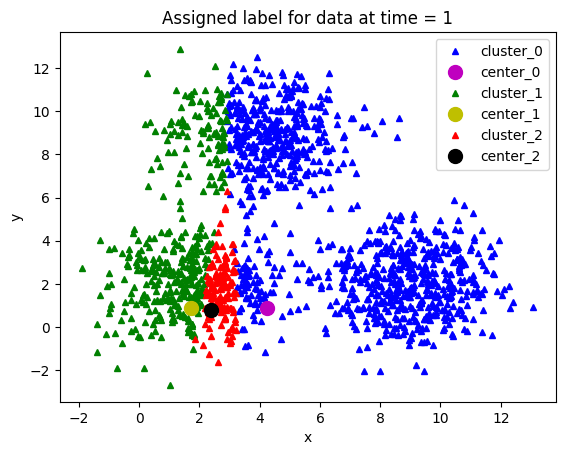

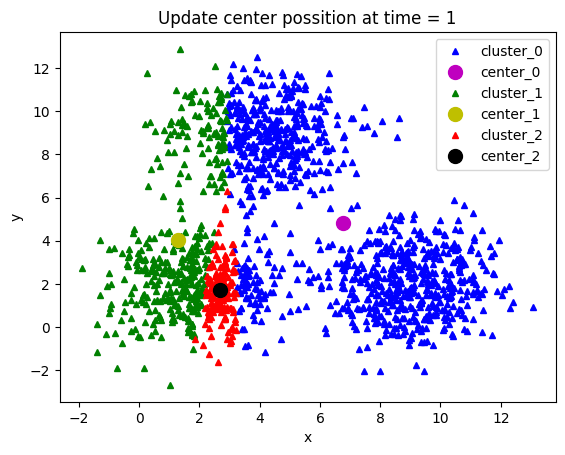

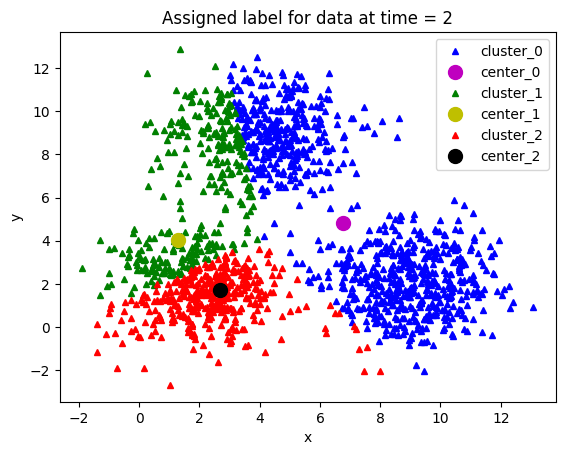

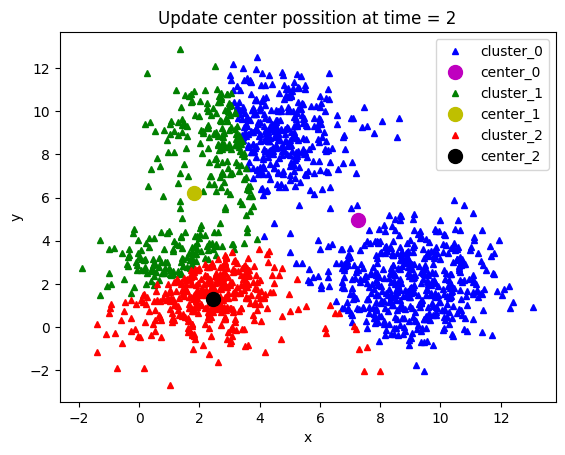

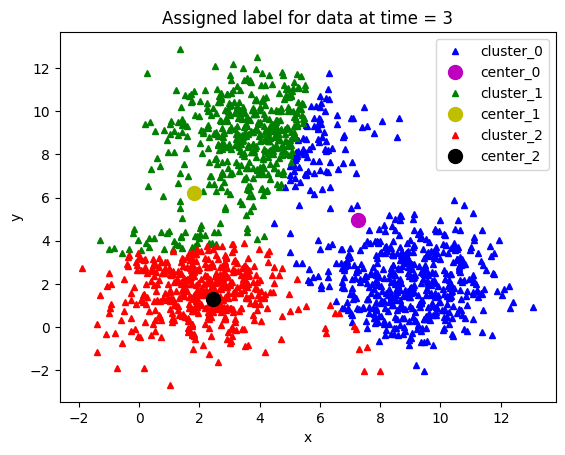

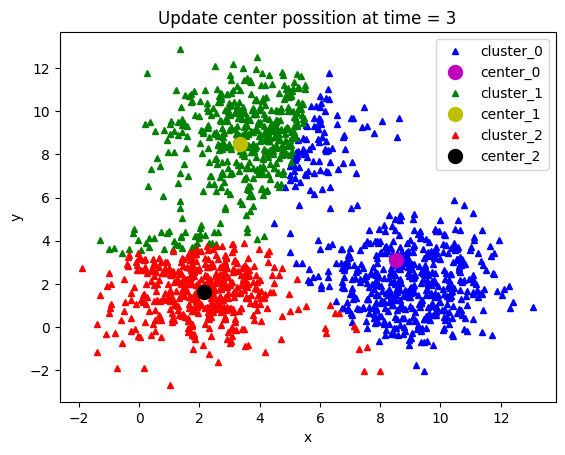

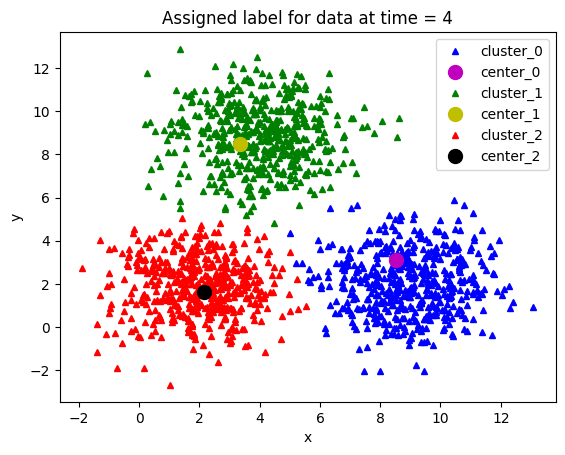

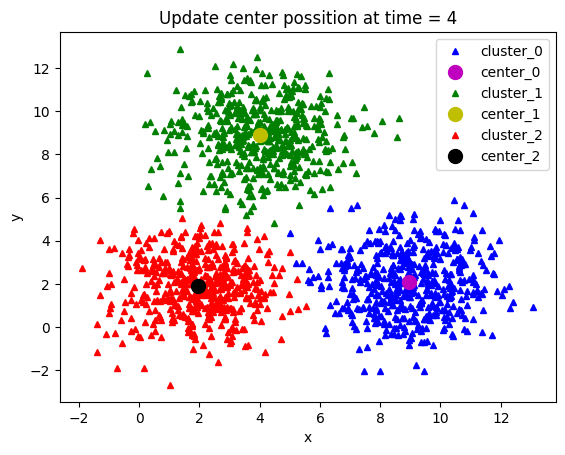

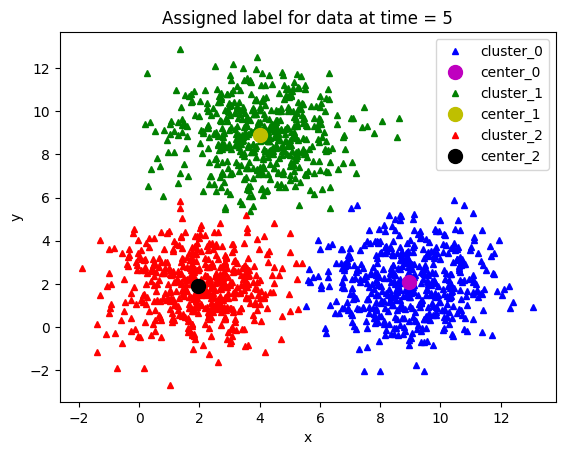

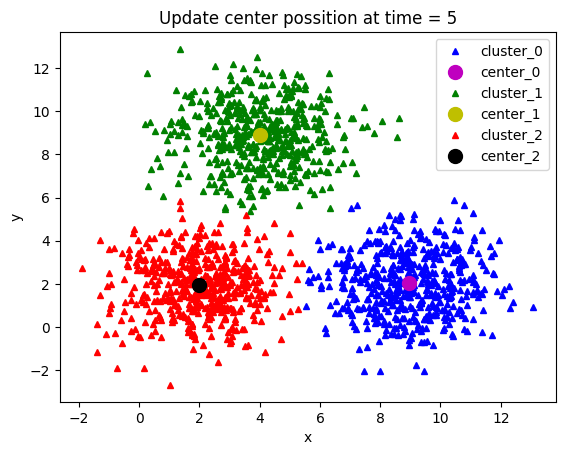

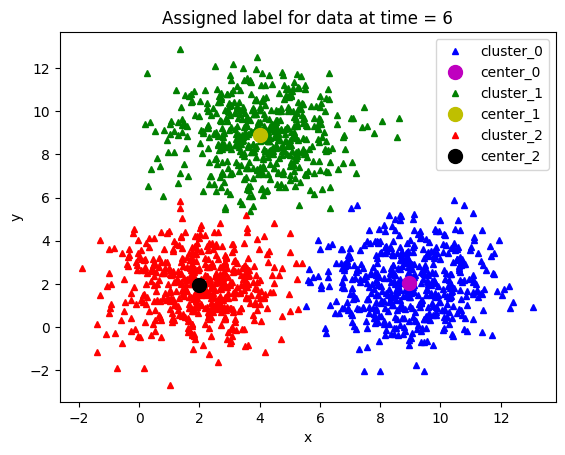

Done! Kmeans has converged after 5 times
[[8.96056256 2.05512291]
 [4.02278693 8.90276476]
 [1.987247   1.93595036]]


In [ ]:
#BAI 1
import numpy as np # thư viện tính toán toán học
import matplotlib.pyplot as plt # visualize data sử dụng đồ thị
from scipy.spatial.distance import cdist # Hỗ trợ tính khoảng cách
means = [[2, 2], [9, 2], [4, 9]]
cov = [[2, 0], [0, 2]]
n_samples = 500
n_cluster = 3
X0 = np.random.multivariate_normal(means[0], cov, n_samples)
X1 = np.random.multivariate_normal(means[1], cov, n_samples)
X2 = np.random.multivariate_normal(means[2], cov, n_samples)
X = np.concatenate((X0, X1, X2), axis = 0)
plt.xlabel('x')
plt.ylabel('y')
plt.plot(X[:, 0], X[:, 1], 'bo', markersize=5)
plt.plot()
plt.show()
def kmeans_init_centers(X, n_cluster):
  # random k index beetween 0 and shape(X) without duplicate index.
  # Then return X[index] as cluster
  return X[np.random.choice(X.shape[0], n_cluster, replace=False)]
def kmeans_predict_labels(X, centers):
  D = cdist(X, centers)
  # return index of the closest center
  return np.argmin(D, axis = 1)
def kmeans_update_centers(X, labels, n_cluster):
  centers = np.zeros((n_cluster, X.shape[1]))
  for k in range(n_cluster):
    # collect all points assigned to the k-th cluster
    Xk = X[labels == k, :]
    # take average
    centers[k,:] = np.mean(Xk, axis = 0)
  return centers
def kmeans_has_converged(centers, new_centers):
  # return True if two sets of centers are the same
  return (set([tuple(a) for a in centers]) ==
      set([tuple(a) for a in new_centers]))
# Hàm này dùng để vẽ dữ liệu lên đồ thị
# Random color chỉ làm việc với k <= 4
# Nếu bạn thay đổi k > 4, hãy sửa lại phần random color nhé
# Chỉ sử dụng trong bài toán này thôi nhé.
def kmeans_visualize(X, centers, labels, n_cluster, title):
  plt.xlabel('x')  # label trục x
  plt.ylabel('y')  # label trục y
  plt.title(title)  # title của đồ thị
  plt_colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'w']  # danh sách các màu hỗ trợ

  for i in range(n_cluster):
    data = X[labels == i]  # lấy dữ liệu của cụm i
    plt.plot(data[:, 0], data[:, 1], plt_colors[i] + '^', markersize=4,
             label='cluster_' + str(i))  # Vẽ cụm i lên đồ thị
    plt.plot(centers[i][0], centers[i][1], plt_colors[i + 4] + 'o', markersize=10,
             label='center_' + str(i))  # Vẽ tâm cụm i lên đồ thị
  plt.legend()  # Hiện bảng chú thích
  plt.show()
def kmeans(init_centes, init_labels, X, n_cluster):
  centers = init_centes
  labels = init_labels
  times = 0
  while True:
    labels = kmeans_predict_labels(X, centers)
    kmeans_visualize(X, centers, labels, n_cluster, 'Assigned label for data at time = ' + str(times + 1))
    new_centers = kmeans_update_centers(X, labels, n_cluster)
    if kmeans_has_converged(centers, new_centers):
      break
    centers = new_centers
    kmeans_visualize(X, centers, labels, n_cluster, 'Update center possition at time = ' + str(times + 1))
    times += 1
  return (centers, labels, times)
init_centers = kmeans_init_centers(X, n_cluster)
print(init_centers)  # In ra tọa độ khởi tạo ban đầu của các tâm cụm
init_labels = np.zeros(X.shape[0])
kmeans_visualize(X, init_centers, init_labels, n_cluster,
                 'Init centers in the first run. Assigned all data as cluster 0')
centers, labels, times = kmeans(init_centers, init_labels, X, n_cluster)

print('Done! Kmeans has converged after', times, 'times')
print(centers)


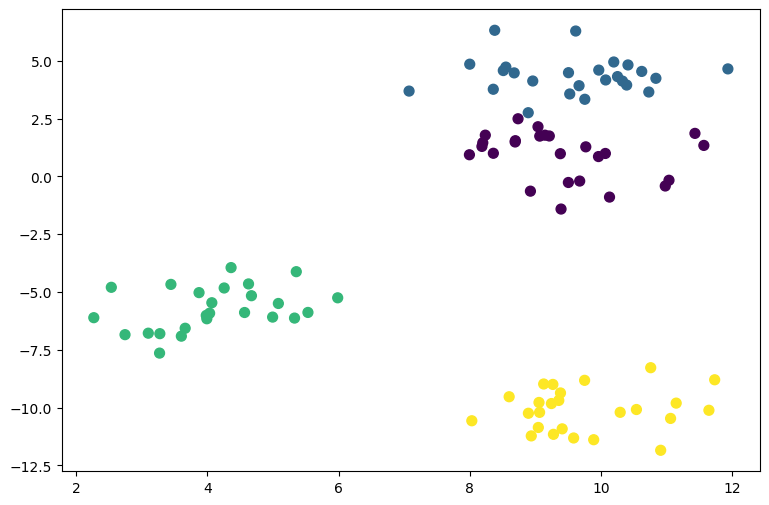

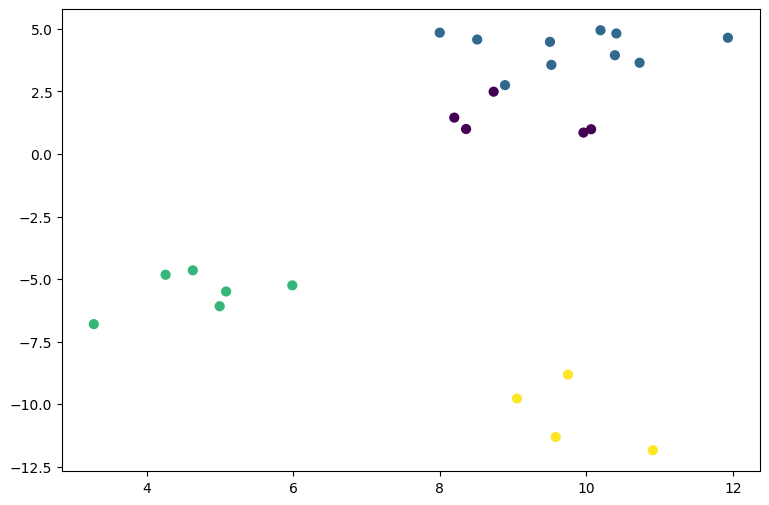

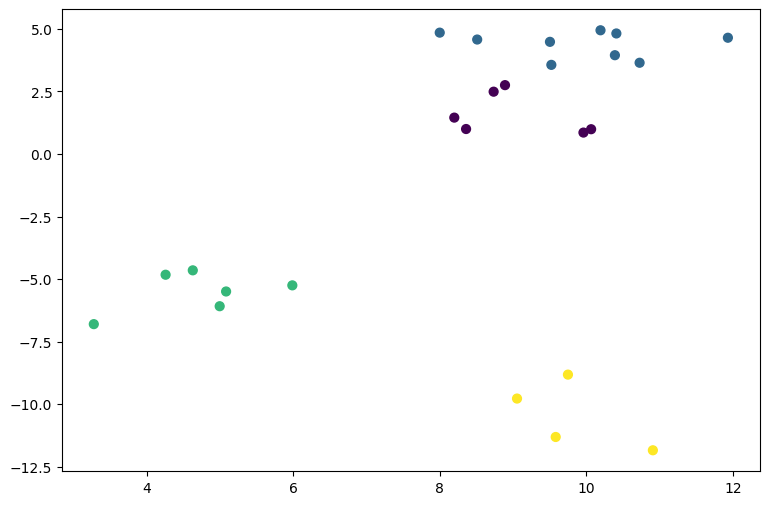

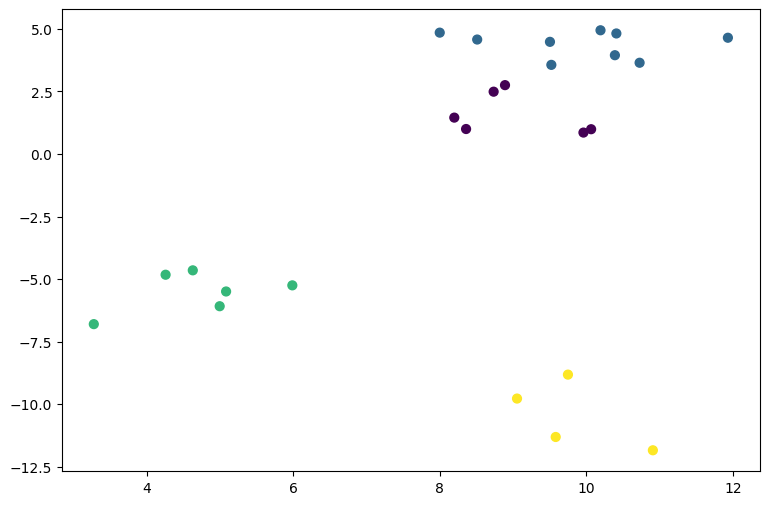

{'n_neighbors': np.int64(2)}
[0]


In [ ]:
#BÀI 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt  # datavisualization
from sklearn.datasets import make_blobs  # synthetic dataset
from sklearn.neighbors import KNeighborsClassifier  # kNN classifier
from sklearn.model_selection import train_test_split  # train and test sets
X,y = make_blobs(n_samples = 100, n_features = 2, centers = 4, cluster_std = 1, random_state = 4)
plt.figure(figsize=(9, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, marker='o', s=50)
plt.show()
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=0)

plt.figure(figsize = (9,6))
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, marker= 'o', s=40)
plt.show()
knn5 = KNeighborsClassifier(5)  # k=5
knn5.fit(X_train, y_train)

y_pred_5 = knn5.predict(X_test)

plt.figure(figsize = (9,6))
plt.scatter(X_test[:,0], X_test[:,1], c=y_pred_5, marker= 'o', s=40)
plt.show()
knn1 = KNeighborsClassifier(1)  # k=1
knn1.fit(X_train, y_train)

y_pred_1 = knn1.predict(X_test)

plt.figure(figsize = (9,6))
plt.scatter(X_test[:,0], X_test[:,1], c=y_pred_1, marker= 'o', s=40)
plt.show()
from sklearn.model_selection import GridSearchCV

knn_grid = GridSearchCV(estimator = KNeighborsClassifier(), param_grid={'n_neighbors': np.arange(1,10)}, cv=5)
knn_grid.fit(X,y)

print (knn_grid.best_params_)
def KNN(X_train,X_test,y_train,k):
    num_test = X_test.shape[0] # số lượng dữ liệu test
    num_train = X_train.shape[0] # số lượng dữ liệu train
    # y_pred là một ma trận, mỗi hàng tương ứng là khoảng cách của một điểm dữ liệu trong tập test đối với tất cả các điểm dữ liệu trong tập train
    y_pred = np.zeros((num_test,num_train))
    # duyệt qua mỗi điểm trong tập test
    for i in range(num_test):
    # tương ứng một điểm trong tập test sẽ duyêt qua hết bộ train
        for j in range(num_train):
    # tính khoảng cách tới tập train
            y_pred[i,j] = np.sqrt(np.sum(np.power(X_test[i,:]-X_train[j,:],2)))
    results = []
    # sắp xếp theo chiều tăng dần khoảng cách
    for i in range(len(y_pred)):
        zipped = zip(y_pred[i,:],y_train)
        res = sorted(zipped,key = lambda x:x[0])
        results_topk = res[:k]
    # Đếm số lượng của mỗi class
        classes = {}
        for _,j in results_topk:
            j = int(j)
            if j not in classes:
                classes[j] = 1
            else:
                classes[j] = classes[j] + 1
        # trả về class có số lượng nhiều nhất
        results.append(max(classes,key = classes.get))
    return np.array(results)

(X,y) = make_blobs(n_samples = 500, n_features = 2, centers = 4, cluster_std = 1, random_state = 4)
X_test=np.array([(1,3)])
results = KNN(X,X_test,y,3)
print (results)




/tmp/ipykernel_11764/1901936963.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


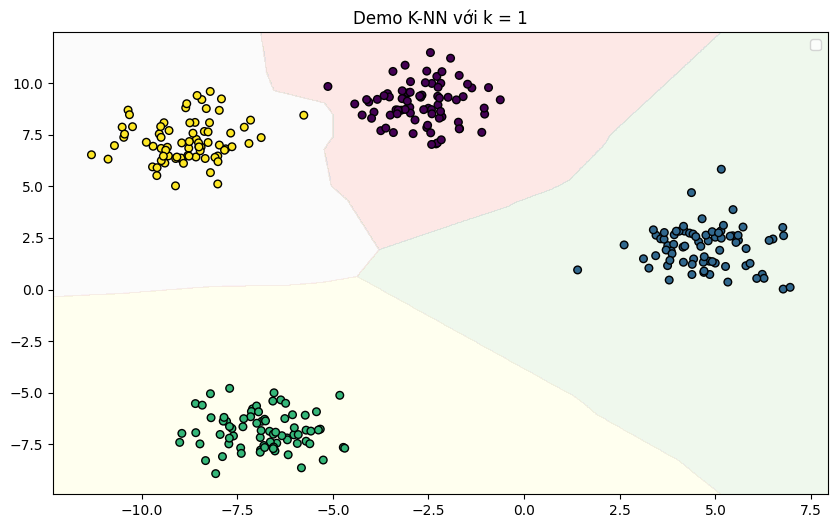

In [7]:
#BÀI 3
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
import ipywidgets as widgets
from IPython.display import display, clear_output

# 1. Khởi tạo dữ liệu mẫu
X, y = make_blobs(n_samples=300, centers=4, cluster_std=1.0, random_state=42)

def run_demo(algo, k):
    plt.figure(figsize=(10, 6))

    if algo == 'K-Means (Phân cụm)':
        # Chạy K-Means
        model = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = model.fit_predict(X)
        centroids = model.cluster_centers_

        plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=30, alpha=0.7)
        plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Tâm cụm')
        plt.title(f"Demo K-Means với k = {k}")

    else:
        # Chạy K-NN (Giả định phân lớp tập dữ liệu hiện tại)
        model = KNeighborsClassifier(n_neighbors=k)
        model.fit(X, y)

        # Vẽ ranh giới phân lớp (Decision Boundary)
        h = .02
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        plt.contourf(xx, yy, Z, alpha=0.3, cmap='Pastel1')
        plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k', s=30)
        plt.title(f"Demo K-NN với k = {k}")

    plt.legend()
    plt.show()

# 2. Tạo giao diện tương tác
algo_select = widgets.Dropdown(
    options=['K-Means (Phân cụm)', 'K-NN (Phân lớp)'],
    value='K-Means (Phân cụm)',
    description='Thuật toán:',
)

k_slider = widgets.IntSlider(
    value=3,
    min=1,
    max=10,
    step=1,
    description='Giá trị k:',
)

# Hàm cập nhật khi thay đổi widget
def update_view(change):
    clear_output(wait=True)
    display(ui)
    run_demo(algo_select.value, k_slider.value)

algo_select.observe(update_view, names='value')
k_slider.observe(update_view, names='value')

ui = widgets.HBox([algo_select, k_slider])
display(ui)
run_demo(algo_select.value, k_slider.value)